In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [4]:
# Subset Olink RVAT significant

olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o /home/dnanexus/data_dir/

olink_whitelist = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o /home/dnanexus/data_dir/

olink_corrs = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_correlations_file}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
)

olink_whitelist = olink_whitelist.select(['region', 'phenotype', 'loftee_corr_dir'])
olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_reg
ression_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr_dir
str,str,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",1.0
…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",1.0


In [5]:
# EUR unrelated individuals

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/sample_lists/unrelated_cauc_samples_3rd_degree.csv -o /home/dnanexus/data_dir/

unrel_eur_samples = pl.read_csv('/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv')['eid'].cast(pl.Utf8).to_list()
unrel_eur_samples[:5]

Error: path "/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv"
already exists but -f/--overwrite was not set


['1000020', '1000107', '1000161', '1000172', '1000221']

In [9]:
# prot_file = "cauc_cov_regression_90pcs_prs"  # covariates and PRS corrected
# prot_file = "cauc_protrider_lite_prs_rint"   # PROTRIDER corrected (RINT)
prot_file = "cauc_protrider_lite_prs_t_df"     # PROTRIDER corrected (T distribution)

# Download Olink:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/adjusted/{prot_file}.parquet -o /home/dnanexus/data_dir/


phenos = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{prot_file}.parquet')
    # .rename({'individual':'sample'})
    .filter(pl.col('sample').is_in(unrel_eur_samples))
)

olink_genes2use = list(set(phenos.columns).intersection(set(olink_whitelist['region'])))

phenos = phenos.select(['sample'] + olink_genes2use)

long_phenos_int = (
    phenos
    .unpivot(
        index='sample',
        on=olink_genes2use,
        variable_name='phenotype',
        value_name='pheno_value'
    )
    .drop_nulls()

    .with_columns(
        # region = pl.col('phenotype'),
        phenotype = pl.col('phenotype') + '_olink',
    )
    
    .join(
        olink_whitelist,
        on='phenotype',
        how='inner'
    )
)

print(long_phenos_int['phenotype'].value_counts(sort=True))
long_phenos_int

Error: path "/home/dnanexus/data_dir/cauc_protrider_lite_prs_t_df.parquet"
already exists but -f/--overwrite was not set
shape: (1_119, 2)
┌───────────────────────┬───────┐
│ phenotype             ┆ count │
│ ---                   ┆ ---   │
│ str                   ┆ u64   │
╞═══════════════════════╪═══════╡
│ ENSG00000130513_olink ┆ 39208 │
│ ENSG00000108821_olink ┆ 39208 │
│ ENSG00000167434_olink ┆ 39208 │
│ ENSG00000069702_olink ┆ 39208 │
│ ENSG00000170323_olink ┆ 39208 │
│ …                     ┆ …     │
│ ENSG00000125730_olink ┆ 31897 │
│ ENSG00000184530_olink ┆ 31679 │
│ ENSG00000000971_olink ┆ 31668 │
│ ENSG00000152229_olink ┆ 31635 │
│ ENSG00000111405_olink ┆ 30953 │
└───────────────────────┴───────┘


sample,phenotype,pheno_value,region,loftee_corr_dir
str,str,f64,str,f64
"""5645319""","""ENSG00000166394_olink""",-0.615783,"""ENSG00000166394""",1.0
"""5959139""","""ENSG00000166394_olink""",0.015376,"""ENSG00000166394""",1.0
"""5732867""","""ENSG00000166394_olink""",-0.671637,"""ENSG00000166394""",1.0
"""2074480""","""ENSG00000166394_olink""",-3.105533,"""ENSG00000166394""",1.0
"""4659532""","""ENSG00000166394_olink""",-0.618132,"""ENSG00000166394""",1.0
…,…,…,…,…
"""1807196""","""ENSG00000173402_olink""",4.467399,"""ENSG00000173402""",1.0
"""4223555""","""ENSG00000173402_olink""",-0.152292,"""ENSG00000173402""",1.0
"""2992773""","""ENSG00000173402_olink""",-0.361321,"""ENSG00000173402""",1.0


In [10]:
mac = 20

RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"

LOCAL_DIR = '/home/dnanexus/data_dir/'

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_DIR}/{ANNO_FILE}

id_list = (
    pl.scan_parquet(f'{LOCAL_DIR}/{ANNO_FILE}')
    .filter(
        pl.col('region').is_in(olink_whitelist.select('region').unique().to_series()),
        pl.col('mac_ukb')<=mac,
        pl.col('loftee_hc')==1,
    )
    .select(['id', 'region'])
    .unique()
    .collect()
)

id_list

Error: path
"/home/dnanexus/data_dir//annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_164891/2405005967.py:21: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region
str,str
"""chr12:111766998:GC:G""","""ENSG00000111275"""
"""chr1:157520498:G:GC""","""ENSG00000143297"""
"""chr5:135951238:G:A""","""ENSG00000145826"""
"""chr5:84064780:GC:G""","""ENSG00000164176"""
"""chr3:155084231:C:T""","""ENSG00000196549"""
…,…
"""chr17:75131604:TGCGGCTCCTCAGGG…","""ENSG00000125458"""
"""chr10:129536378:G:A""","""ENSG00000170430"""
"""chr11:62491736:A:AT""","""ENSG00000124942"""


In [11]:
# Download genotype (long gt) file
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/gt_long.parquet -o /home/dnanexus/data_dir/

long_gt = (
    pl.scan_parquet('/home/dnanexus/data_dir/gt_long.parquet')
    .select(['id', 'sample', 'gt'])
    .filter(pl.col('sample').is_in(unrel_eur_samples))

    # Step 1: Semi join to filter down to only relevant variants
    .join(
        id_list.select('id').unique().lazy(),
        on='id',
        how='semi',
    )

    # Step 2: Inner join to bring in region then compute burden
    .join(
        id_list.lazy(), 
        on='id', 
        how='inner'
    )
    .group_by(['region', 'sample'])
    .agg(
        burden=pl.col('gt').sum().cast(pl.Int32)
    )
    
    .collect(engine='streaming')
)

long_gt

Error: path "/home/dnanexus/data_dir/gt_long.parquet" already exists but
-f/--overwrite was not set


region,sample,burden
str,str,i32
"""ENSG00000176834""","""3470933""",1
"""ENSG00000123146""","""4716127""",1
"""ENSG00000116977""","""1082204""",1
"""ENSG00000116977""","""5874197""",1
"""ENSG00000021852""","""2830705""",1
…,…,…
"""ENSG00000104687""","""1135565""",1
"""ENSG00000042832""","""4013338""",1
"""ENSG00000107201""","""6019893""",1


In [12]:
loftee_pheno = (
    long_phenos_int
    .join(
        long_gt,
        on=['sample', 'region'],
        how='inner'
    )
    .with_columns(
        pheno_value_dircorr = pl.col('pheno_value')*pl.col('loftee_corr_dir'),
        burden_categories = pl.col('burden').cast(pl.Utf8).cast(pl.Categorical)
    )
)

loftee_pheno

sample,phenotype,pheno_value,region,loftee_corr_dir,burden,pheno_value_dircorr,burden_categories
str,str,f64,str,f64,i32,f64,cat
"""2187509""","""ENSG00000166394_olink""",-2.827122,"""ENSG00000166394""",1.0,1,-2.827122,"""1"""
"""4591264""","""ENSG00000166394_olink""",-3.294377,"""ENSG00000166394""",1.0,1,-3.294377,"""1"""
"""5964295""","""ENSG00000166394_olink""",-1.362527,"""ENSG00000166394""",1.0,1,-1.362527,"""1"""
"""2252981""","""ENSG00000166394_olink""",-1.09956,"""ENSG00000166394""",1.0,1,-1.09956,"""1"""
"""4303735""","""ENSG00000166394_olink""",-1.788498,"""ENSG00000166394""",1.0,1,-1.788498,"""1"""
…,…,…,…,…,…,…,…
"""3254389""","""ENSG00000008710_olink""",-1.664342,"""ENSG00000008710""",1.0,1,-1.664342,"""1"""
"""2681112""","""ENSG00000173402_olink""",-4.019628,"""ENSG00000173402""",1.0,1,-4.019628,"""1"""
"""4534699""","""ENSG00000173402_olink""",-3.983776,"""ENSG00000173402""",1.0,1,-3.983776,"""1"""


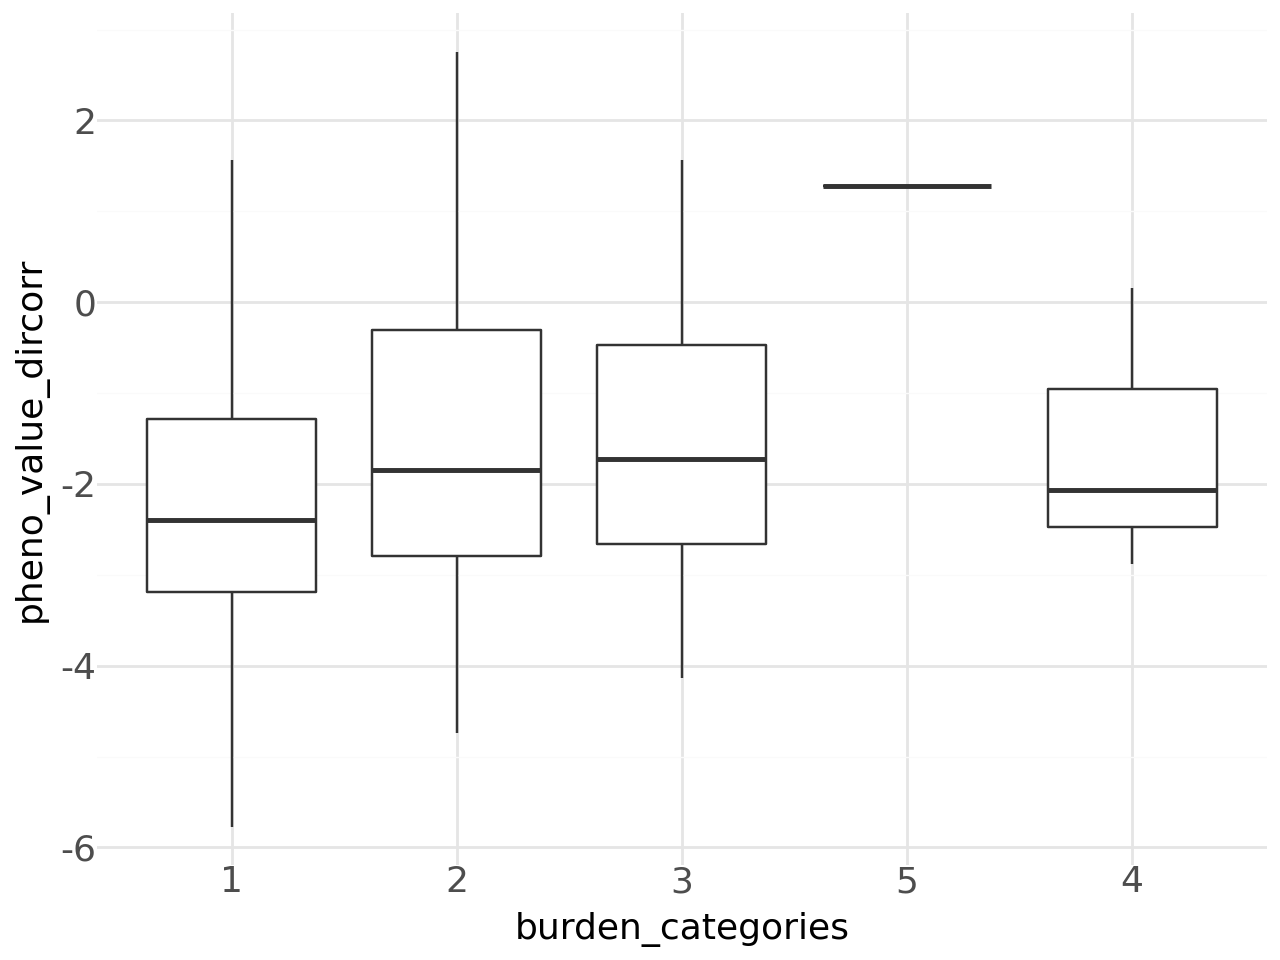

In [13]:
(
    ggplot(
        loftee_pheno, 
        # loftee_pheno.filter(pl.col('burden')==1), 
        aes(x='burden_categories', y='pheno_value_dircorr')
    )
    + geom_boxplot(outlier_shape=None)
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [14]:
loftee_pheno_avg = (
    loftee_pheno
    .group_by(['burden_categories'])
    .agg(
        n_individuals = pl.len().cast(pl.Int32),
        mean_pheno_value = pl.col('pheno_value_dircorr').mean().cast(pl.Float32),
        std_pheno_value = pl.col('pheno_value_dircorr').std().cast(pl.Float32),
    )
    .with_columns(
        ci_lower = pl.col('mean_pheno_value') - 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt()),
        ci_upper = pl.col('mean_pheno_value') + 1.96 * (pl.col('std_pheno_value') / pl.col('n_individuals').sqrt())
    )
)

loftee_pheno_avg

burden_categories,n_individuals,mean_pheno_value,std_pheno_value,ci_lower,ci_upper
cat,i32,f32,f32,f64,f64
"""5""",1,1.281854,null,null,null
"""1""",10574,-2.100129,1.554833,-2.129765,-2.070493
"""2""",137,-1.52016,1.693218,-1.803696,-1.236623
"""4""",3,-1.600422,1.569781,-3.376797,0.175952
"""3""",29,-1.712006,1.72418,-2.339543,-1.084468


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 1 rows containing missing values.


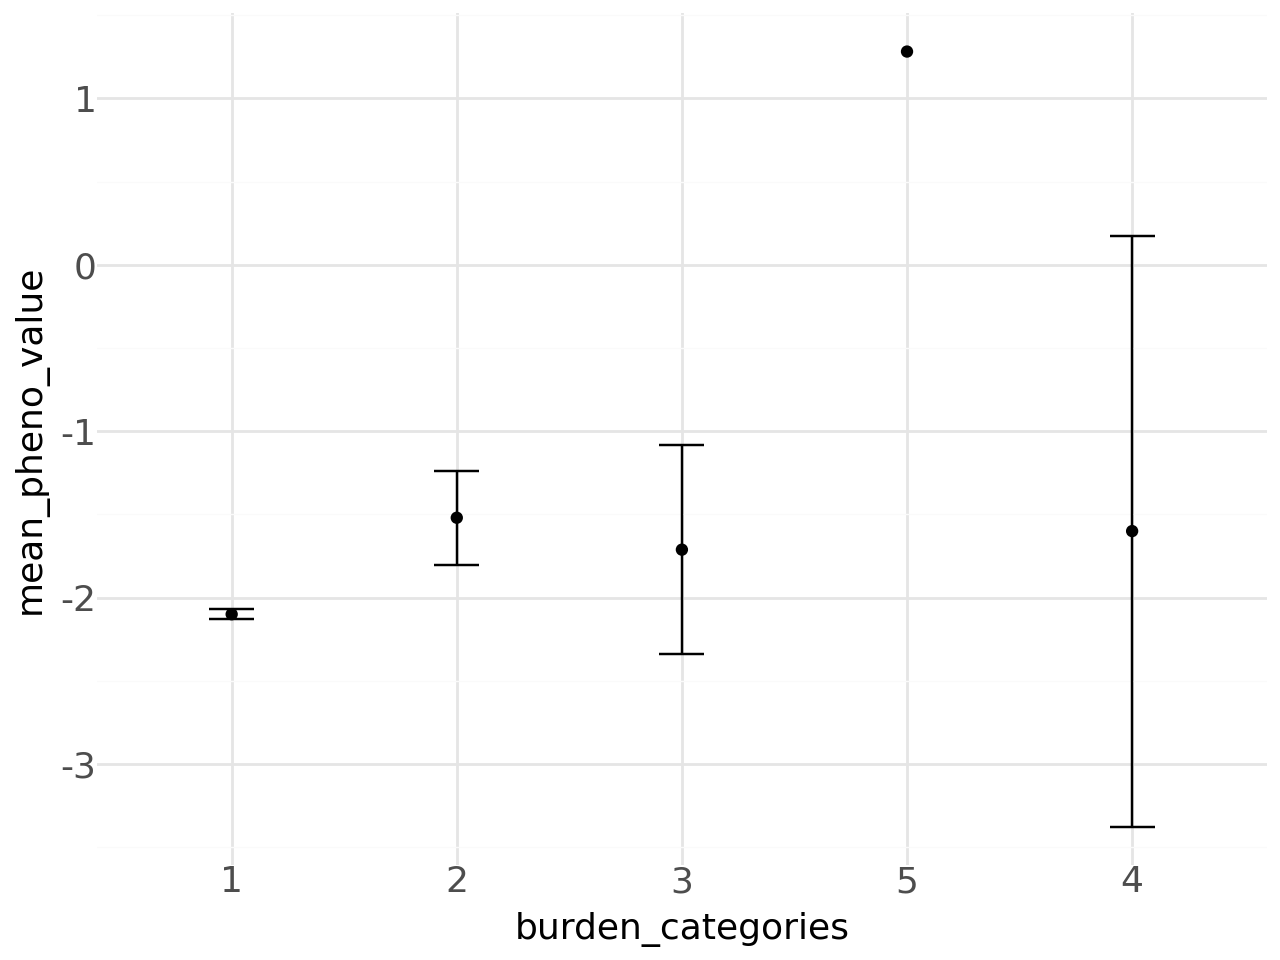

In [15]:
(
    ggplot(
        loftee_pheno_avg,
        aes(x='burden_categories', y='mean_pheno_value')
    )
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin='ci_lower', ymax='ci_upper'), width=0.2)
    + theme_minimal()
    + theme(
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)